# Workflow for importing, processing, aggregating, and importing CORDEX ensemble stats for Norway precipitation

In [1]:
import json
import pandas as pd
import geopandas as gpd
import xarray as xr
from dhis2eo.data.cds import cordex
from dhis2_client import DHIS2Client
from dhis2eo.integrations.pandas import dataframe_to_dhis2_json

In [ ]:
# Params
# DHIS2_BASE_URL = 'https://climate.im.dhis2.org/climate-projections-42'
# DHIS2_USERNAME = 'admin'
# DHIS2_PASSWORD = 'district'
# DHIS2_ORG_UNIT_LEVEL = 2

In [2]:
# Connect
# client = DHIS2Client(
#     base_url=DHIS2_BASE_URL,
#     username=DHIS2_USERNAME,
#     password=DHIS2_PASSWORD,
# )
# info = client.get_system_info()

# # Check if everything is working.
# # You should see your current DHIS2 version info.
# print("Current DHIS2 version:", info["version"])

# ### Get org units GeoJSON from DHIS2
# org_units_geojson = client.get_org_units_geojson(level=DHIS2_ORG_UNIT_LEVEL)

# # Convert GeoJSON to geopandas
# org_units = gpd.read_file(json.dumps(org_units_geojson))
org_units = gpd.read_file('../test_data/geoBoundaries-NOR-ADM2_simplified.geojson')
org_units

,shapeName,shapeISO,shapeID,shapeGroup,shapeType,geometry
0,Vadsø nor,,86288312B60394141718177,NOR,ADM2,"POLYGON ((30.07432 70.29641, 29.98651 70.31219..."
1,Osen nor,,86288312B40278854732862,NOR,ADM2,"MULTIPOLYGON (((10.29404 64.3031, 10.28877 64...."
2,Bremanger nor,,86288312B98133792313273,NOR,ADM2,"MULTIPOLYGON (((4.84488 61.81111, 4.82711 61.8..."
3,Austevoll nor,,86288312B29393912466053,NOR,ADM2,"MULTIPOLYGON (((5.18801 60.01652, 5.18138 60.0..."
4,Kristiansand nor,,86288312B34972554267052,NOR,ADM2,"MULTIPOLYGON (((7.99788 58.09287, 7.9949 58.09..."
...,...,...,...,...,...,...
426,Snåase sma 1,,86288312B29366905893457,NOR,ADM2,"POLYGON ((12.68357 63.97422, 12.92672 64.05795..."
427,Aurskog-Høland nor,,86288312B17302655292255,NOR,ADM2,"POLYGON ((11.92698 59.79059, 11.92606 59.79379..."
428,Kåfjord nor 2,,86288312B7453580545213,NOR,ADM2,"POLYGON ((20.46265 69.7587, 20.49033 69.75383,..."
429,Fuossko smj 2,,86288312B90819759899265,NOR,ADM2,"POLYGON ((15.16845 67.4099, 15.16598 67.4019, ..."


## Download and save to reduced file format

In [4]:
# begin
start_year = 2061
end_year = 2095
dirname = '../test_outputs/cordex/norway'
variables = ['mean_precipitation_flux']
region = 'europe'
bbox = list(map(float, org_units.total_bounds))
resolution = '0_11_degree_x_0_11_degree'
scenarios = ['rcp_8_5']

import logging
logging.basicConfig(level='INFO')

files = []
for scenario in scenarios:
    print('Scenario', scenario)
    prefix = f'cordex_precip'  # TODO: been using wrong prefix should rename old files to _precip_
    scenario_models = cordex.MODELS[region][resolution][scenario]
    subfiles = cordex.daily.download(start_year, end_year, region, dirname, prefix, variables, scenario, resolution, 
                                     scenario_models, clean=True, bbox=bbox, overwrite=False)
    print('-->', subfiles)
    files.extend(subfiles)

files

Scenario rcp_8_5


INFO:dhis2eo.data.cds.cordex.daily:GCM model cccma_canesm2
INFO:dhis2eo.data.cds.cordex.daily:RCM model gerics_remo2015
INFO:dhis2eo.data.cds.cordex.daily:Ensemble r1i1p1
INFO:dhis2eo.data.cds.cordex.daily:Years 2061 to 2065
INFO:dhis2eo.data.cds.cordex.daily:File already exists, reusing from cache C:\Users\karimba\Documents\Github\dhis2eo\tests\test_outputs\cordex\norway\cordex_precip_rcp-8-5_cccma-canesm2_gerics-remo2015_r1i1p1_2061-2065.nc
INFO:dhis2eo.data.cds.cordex.daily:Years 2066 to 2070
INFO:dhis2eo.data.cds.cordex.daily:File already exists, reusing from cache C:\Users\karimba\Documents\Github\dhis2eo\tests\test_outputs\cordex\norway\cordex_precip_rcp-8-5_cccma-canesm2_gerics-remo2015_r1i1p1_2066-2070.nc
INFO:dhis2eo.data.cds.cordex.daily:Years 2071 to 2075
INFO:dhis2eo.data.cds.cordex.daily:File already exists, reusing from cache C:\Users\karimba\Documents\Github\dhis2eo\tests\test_outputs\cordex\norway\cordex_precip_rcp-8-5_cccma-canesm2_gerics-remo2015_r1i1p1_2071-2075.nc
I

db2c95a93258249881a4f063d38957dc.zip:   0%|          | 0.00/570M [00:00<?, ?B/s]

INFO:multiurl.base:Downloading https://object-store.os-api.cci2.ecmwf.int:443/cci2-prod-cache-3/2026-03-01/6d4a00c41e192017e81978cd2b4aa4a5.zip


6d4a00c41e192017e81978cd2b4aa4a5.zip:   0%|          | 0.00/625M [00:00<?, ?B/s]

...

INFO:dhis2eo.data.cds.cordex.daily:Finished downloading to C:\Users\karimba\Documents\Github\dhis2eo\tests\test_outputs\cordex\norway\cordex_precip_rcp-8-5_mpi-m-mpi-esm-lr_mpi-csc-remo2009_r1i1p1_2071-2075.nc
INFO:dhis2eo.data.cds.cordex.daily:Processing download request 418 of 419
INFO:dhis2eo.data.cds.cordex.daily:Requesting climate projection data from CDS API...
INFO:dhis2eo.data.cds.cordex.daily:Request parameters: 
{"domain": "europe", "experiment": "rcp_8_5", "horizontal_resolution": "0_11_degree_x_0_11_degree", "temporal_resolution": "daily_mean", "variable": ["mean_precipitation_flux"], "gcm_model": "mpi_m_mpi_esm_lr", "rcm_model": "mpi_csc_remo2009", "ensemble_member": "r2i1p1", "start_year": ["2091"], "end_year": ["2095"]}
INFO:ecmwf.datastores.processing:Request ID is 59024d58-cc66-482d-b4a4-be7a8b72ebed
INFO:dhis2eo.data.cds.cordex.daily:Waiting for results and downloading to C:\Users\karimba\Documents\Github\dhis2eo\tests\test_outputs\cordex\norway\cordex_precip_rcp-8-5_

b57fdc16599921e087b05e958e2893cb.zip:   0%|          | 0.00/998M [00:00<?, ?B/s]

INFO:dhis2eo.data.cds.cordex.daily:Cleaning and optimizing file
INFO:dhis2eo.data.cds.cordex.daily:Cropping to bbox
INFO:dhis2eo.data.cds.cordex.daily:Finished downloading to C:\Users\karimba\Documents\Github\dhis2eo\tests\test_outputs\cordex\norway\cordex_precip_rcp-8-5_mpi-m-mpi-esm-lr_mpi-csc-remo2009_r1i1p1_2086-2090.nc
INFO:dhis2eo.data.cds.cordex.daily:Finished downloading to C:\Users\karimba\Documents\Github\dhis2eo\tests\test_outputs\cordex\norway\cordex_precip_rcp-8-5_mpi-m-mpi-esm-lr_mpi-csc-remo2009_r1i1p1_2091-2095.nc
INFO:dhis2eo.data.cds.cordex.daily:Cleaning and optimizing file
INFO:dhis2eo.data.cds.cordex.daily:Cropping to bbox
INFO:dhis2eo.data.cds.cordex.daily:Finished downloading to C:\Users\karimba\Documents\Github\dhis2eo\tests\test_outputs\cordex\norway\cordex_precip_rcp-8-5_mpi-m-mpi-esm-lr_mpi-csc-remo2009_r1i1p1_2081-2085.nc
INFO:dhis2eo.data.cds.cordex.daily:Cleaning and optimizing file
INFO:dhis2eo.data.cds.cordex.daily:Cropping to bbox
INFO:dhis2eo.data.cds.

--> [WindowsPath('C:/Users/karimba/Documents/Github/dhis2eo/tests/test_outputs/cordex/norway/cordex_precip_rcp-8-5_cccma-canesm2_gerics-remo2015_r1i1p1_2061-2065.nc'), WindowsPath('C:/Users/karimba/Documents/Github/dhis2eo/tests/test_outputs/cordex/norway/cordex_precip_rcp-8-5_cccma-canesm2_gerics-remo2015_r1i1p1_2066-2070.nc'), WindowsPath('C:/Users/karimba/Documents/Github/dhis2eo/tests/test_outputs/cordex/norway/cordex_precip_rcp-8-5_cccma-canesm2_gerics-remo2015_r1i1p1_2071-2075.nc'), WindowsPath('C:/Users/karimba/Documents/Github/dhis2eo/tests/test_outputs/cordex/norway/cordex_precip_rcp-8-5_cccma-canesm2_gerics-remo2015_r1i1p1_2076-2080.nc'), WindowsPath('C:/Users/karimba/Documents/Github/dhis2eo/tests/test_outputs/cordex/norway/cordex_precip_rcp-8-5_cccma-canesm2_gerics-remo2015_r1i1p1_2081-2085.nc'), WindowsPath('C:/Users/karimba/Documents/Github/dhis2eo/tests/test_outputs/cordex/norway/cordex_precip_rcp-8-5_cccma-canesm2_gerics-remo2015_r1i1p1_2086-2090.nc'), WindowsPath('C:/U

[WindowsPath('C:/Users/karimba/Documents/Github/dhis2eo/tests/test_outputs/cordex/norway/cordex_precip_rcp-8-5_cccma-canesm2_gerics-remo2015_r1i1p1_2061-2065.nc'),
 WindowsPath('C:/Users/karimba/Documents/Github/dhis2eo/tests/test_outputs/cordex/norway/cordex_precip_rcp-8-5_cccma-canesm2_gerics-remo2015_r1i1p1_2066-2070.nc'),
 WindowsPath('C:/Users/karimba/Documents/Github/dhis2eo/tests/test_outputs/cordex/norway/cordex_precip_rcp-8-5_cccma-canesm2_gerics-remo2015_r1i1p1_2071-2075.nc'),
 WindowsPath('C:/Users/karimba/Documents/Github/dhis2eo/tests/test_outputs/cordex/norway/cordex_precip_rcp-8-5_cccma-canesm2_gerics-remo2015_r1i1p1_2076-2080.nc'),
 WindowsPath('C:/Users/karimba/Documents/Github/dhis2eo/tests/test_outputs/cordex/norway/cordex_precip_rcp-8-5_cccma-canesm2_gerics-remo2015_r1i1p1_2081-2085.nc'),
 WindowsPath('C:/Users/karimba/Documents/Github/dhis2eo/tests/test_outputs/cordex/norway/cordex_precip_rcp-8-5_cccma-canesm2_gerics-remo2015_r1i1p1_2086-2090.nc'),
 WindowsPath('C:

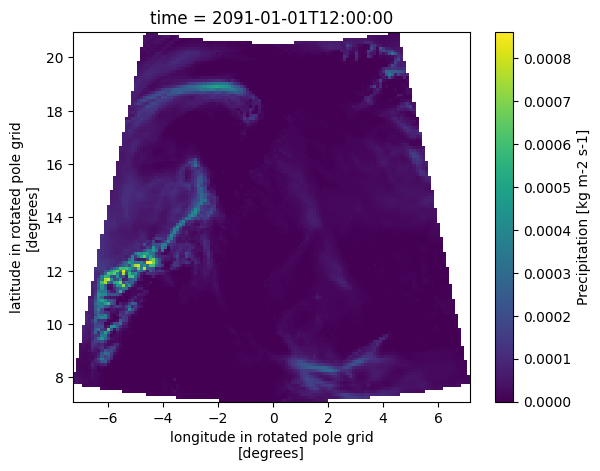

In [4]:
xr.open_dataset(str(files[-1]))['pr'].isel(time=0).plot() #.rotated_pole.encoding #.replace('.nc', '.bbox.nc')

In [50]:
# generate reference cordex xarray ds
import cordex as cx
d = cx.domain('EUR-11')

# get bbox
xmin,ymin,xmax,ymax = map(float, org_units.total_bounds)

# crop to org units
xres = abs(d.lon.max() - d.lon.min()) / len(d.rlon)
yres = abs(d.lat.max() - d.lat.min()) / len(d.rlat)
mask = (
    (d.lat >= (ymin-yres)) & (d.lat <= (ymax+yres)) &
    (d.lon >= (xmin-xres))  & (d.lon <= (xmax+xres))
).compute()
d = d.where(mask, drop=True).compute()

print(d.lon.sizes, d.lon.values.min(), d.lon.values.max())
print(d.lat.sizes, d.lat.values.min(), d.lat.values.max())

cordex_grid = d
cordex_grid

Frozen({'rlat': 126, 'rlon': 131}) -2.878839189995021 38.31115637488202
Frozen({'rlat': 126, 'rlon': 131}) 57.2968153874755 71.70499949739536


<xarray.Dataset> Size: 398kB
Dimensions:                     (rlat: 126, rlon: 131)
Coordinates:
  * rlat                        (rlat) float64 1kB 7.205 7.315 ... 20.84 20.95
  * rlon                        (rlon) float64 1kB -7.255 -7.145 ... 6.935 7.045
    lon                         (rlat, rlon) float64 132kB 4.592 4.79 ... 38.31
    lat                         (rlat, rlon) float64 132kB 57.3 57.32 ... 70.73
Data variables:
    rotated_latitude_longitude  (rlat, rlon) float64 132kB nan nan ... nan nan
Attributes:
    CORDEX_domain:  EUR-11

In [52]:
# collect and prep files before concat
datasets = []
#subfiles = [f for f in files if str(f).endswith('2021-2025.nc')]
for fil in files:

    # open dataset
    print('-------->', fil)
    d = xr.open_dataset(fil) #, chunks={"time": 360}) #, "rlat": 100, "rlon": 100})
    if hasattr(d, 'Lambert_Conformal'):
        print('Skipping lambert projection!')
        continue
    # print(d.lon.sizes, d.lon.values.min(), d.lon.values.max())
    # print(d.lat.sizes, d.lat.values.min(), d.lat.values.max())

    # snap to reference grid
    d = d.reindex(
        rlat=cordex_grid.rlat,
        rlon=cordex_grid.rlon,
        method="nearest",
        tolerance=0.06,
    )
    d = d.assign_coords({'lon': cordex_grid.lon, 'lat': cordex_grid.lat})
    #d = d.dropna(dim="rlat", how="all").dropna(dim="rlon", how="all")
    # print(d.lon.sizes, d.lon.values.min(), d.lon.values.max())
    # print(d.lat.sizes, d.lat.values.min(), d.lat.values.max())
    #d['pr'].isel(time=0).plot()

    # convert precipitation flux per second (kg m-2 s-1) to daily 
    # 1 kg/m2 of water is equivalent to 1mm of liquid water depth
    d['pr'] *= 86400 # seconds per day
    
    # aggregate to months to avoid calendar trouble and daily is mostly noise
    grouped = d['pr'].resample(time="MS", skipna=True)
    monthly = xr.Dataset({
        "pr_sum": grouped.sum(dim="time"),
    })
    # print('calendar', subset['time'].encoding.get('calendar'))
    # subset.coords['year_month'] = subset['time'].dt.strftime('%Y-%m')
    # grouped = subset['tas'].groupby('year_month')
    # monthly = xr.Dataset({
    #     "tas_mean": grouped.mean(dim="time"),
    #     "tas_min": grouped.min(dim="time"),
    #     "tas_max": grouped.max(dim="time"),
    #     "count": grouped.count(dim="time"),
    # })
    # monthly = monthly.rename({'year_month': 'time'})
    # monthly['time'] = np.array([np.datetime64(f'{y_m}-01') for y_m in monthly['time'].values])
    # print(monthly)

    # convert to numpy datetime after aggregating to months
    if hasattr(monthly.indexes["time"], 'to_datetimeindex'):
        time = pd.DatetimeIndex([
            pd.Timestamp(t.year, t.month, 1) for t in monthly.time.values
        ])
        monthly = monthly.assign_coords(time=time)
    else:
        print('time dim already in numpy datetime format')
    
    # make gcm-rcm combo a dimension that we can select on after concat
    gcm = d.model_id
    rcm = d.driving_model_id
    ensemble_id = f'{gcm}__{rcm}'
    monthly = monthly.assign_coords(ensemble=ensemble_id).expand_dims("ensemble")
    
    # make scenario a dimension that we can select on after concat
    scenario_id = d.experiment_id
    monthly = monthly.assign_coords(scenario=scenario_id).expand_dims("scenario")
    
    # add to list
    datasets.append(monthly)

--------> C:\Users\karimba\Documents\Github\dhis2eo\tests\test_outputs\cordex\norway\cordex_temperature_rcp_2_6_ichec_ec_earth-gerics_remo2015_2021-2025.nc
time dim already in numpy datetime format
--------> C:\Users\karimba\Documents\Github\dhis2eo\tests\test_outputs\cordex\norway\cordex_temperature_rcp_2_6_ichec_ec_earth-gerics_remo2015_2026-2030.nc
time dim already in numpy datetime format
--------> C:\Users\karimba\Documents\Github\dhis2eo\tests\test_outputs\cordex\norway\cordex_temperature_rcp_2_6_ichec_ec_earth-gerics_remo2015_2031-2035.nc
time dim already in numpy datetime format
--------> C:\Users\karimba\Documents\Github\dhis2eo\tests\test_outputs\cordex\norway\cordex_temperature_rcp_2_6_ichec_ec_earth-gerics_remo2015_2036-2040.nc
time dim already in numpy datetime format
--------> C:\Users\karimba\Documents\Github\dhis2eo\tests\test_outputs\cordex\norway\cordex_temperature_rcp_2_6_ichec_ec_earth-gerics_remo2015_2041-2045.nc
time dim already in numpy datetime format
--------> 

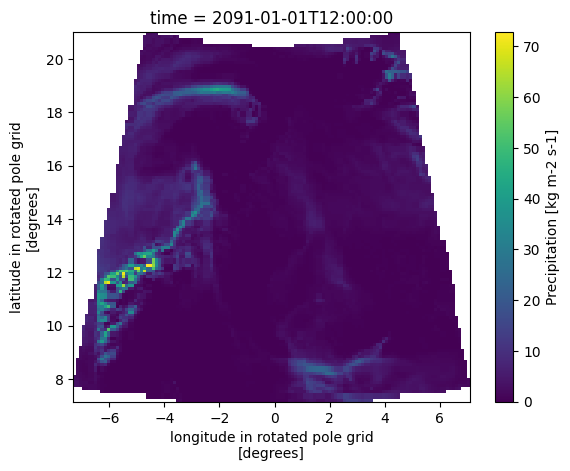

In [56]:
d['pr'].isel(time=0).plot()

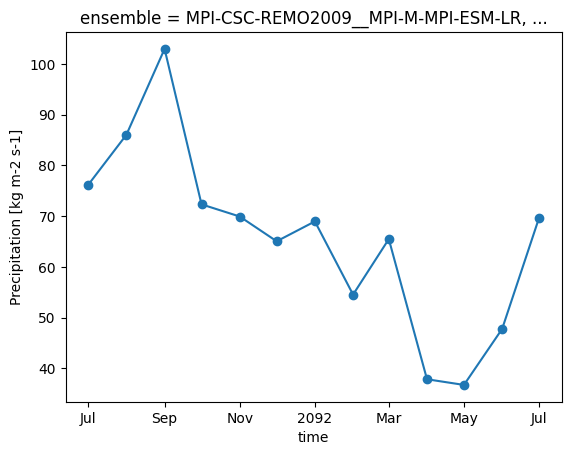

In [55]:
# quick sanity timeseries test for entire country
country = monthly.mean(dim=["rlat","rlon"])
country['pr_sum'].sel(time=slice('2091-07', '2092-07')).plot(x="time", marker="o", linestyle="-", add_legend=False)

In [57]:
# concat
ds = xr.combine_by_coords(
    datasets, 
    compat='override',
    coords='minimal',
    combine_attrs="override",
)
ds

<xarray.Dataset> Size: 1GB
Dimensions:       (scenario: 1, ensemble: 23, time: 900, rlat: 126, rlon: 131)
Coordinates:
  * scenario      (scenario) <U5 20B 'rcp26'
  * ensemble      (ensemble) <U39 4kB 'CLMcom-BTU-CCLM4-8-17__MPI-M-MPI-ESM-L...
  * time          (time) datetime64[ns] 7kB 2021-01-01 2021-02-01 ... 2095-12-01
  * rlat          (rlat) float64 1kB 7.205 7.315 7.425 ... 20.73 20.84 20.95
  * rlon          (rlon) float64 1kB -7.255 -7.145 -7.035 ... 6.825 6.935 7.045
    rotated_pole  |S1 1B ...
    lat           (rlat, rlon) float64 132kB 57.3 57.32 57.34 ... 70.76 70.73
    lon           (rlat, rlon) float64 132kB 4.592 4.79 4.989 ... 38.01 38.31
Data variables:
    pr_sum        (scenario, ensemble, time, rlat, rlon) float32 1GB 0.0 ... 0.0

In [58]:
# save to disk so can reuse later
ds.to_netcdf('../test_outputs/cordex/norway/cordex_precip_norway.nc')

## Run from saved output

In [ ]:
# open from disk
ds = xr.open_dataset('../test_outputs/cordex/cordex_precip_norway.nc')

In [59]:
ds_ens = xr.Dataset({
    "pr_sum_ens_mean": ds['pr_sum'].mean(dim="ensemble"),
    "pr_sum_ens_min": ds['pr_sum'].min(dim="ensemble"),
    "pr_sum_ens_max": ds['pr_sum'].max(dim="ensemble"),
})
ds_ens

<xarray.Dataset> Size: 179MB
Dimensions:          (rlon: 131, rlat: 126, time: 900, scenario: 1)
Coordinates:
  * rlon             (rlon) float64 1kB -7.255 -7.145 -7.035 ... 6.935 7.045
  * rlat             (rlat) float64 1kB 7.205 7.315 7.425 ... 20.73 20.84 20.95
  * time             (time) datetime64[ns] 7kB 2021-01-01 ... 2095-12-01
  * scenario         (scenario) <U5 20B 'rcp26'
    rotated_pole     |S1 1B b''
    lat              (rlat, rlon) float64 132kB 57.3 57.32 57.34 ... 70.76 70.73
    lon              (rlat, rlon) float64 132kB 4.592 4.79 4.989 ... 38.01 38.31
Data variables:
    pr_sum_ens_mean  (scenario, time, rlat, rlon) float32 59MB 0.0 0.0 ... 0.0
    pr_sum_ens_min   (scenario, time, rlat, rlon) float32 59MB 0.0 0.0 ... 0.0
    pr_sum_ens_max   (scenario, time, rlat, rlon) float32 59MB 0.0 0.0 ... 0.0

(57.9743554, 71.1854959)

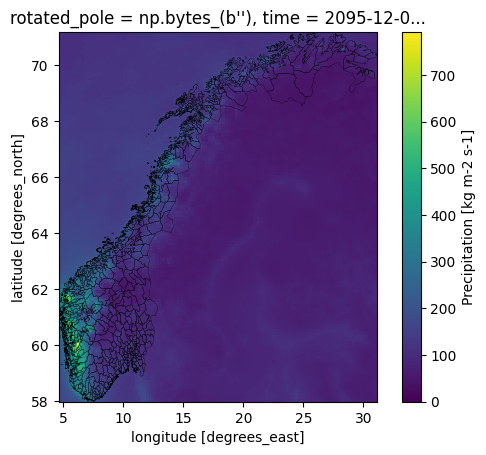

In [70]:
import matplotlib.pyplot as plt
fig,ax = plt.subplots()
grid = ds['pr_sum'].isel(time=-1).sel(scenario='rcp26').mean(dim='ensemble')
grid.plot(ax=ax, x='lon', y='lat')
org_units.plot(ax=ax, color='none', linewidth=0.2)
xmin,ymin,xmax,ymax = org_units.total_bounds
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

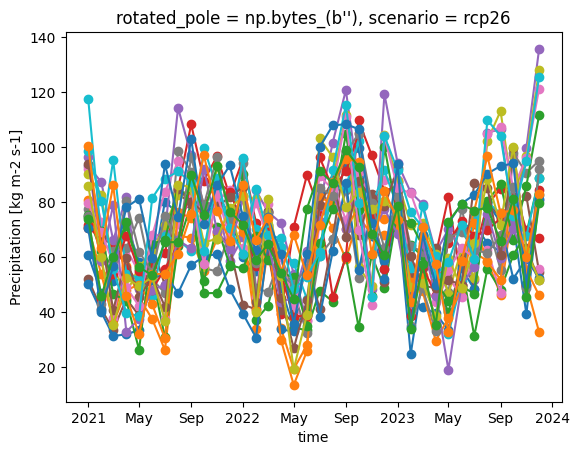

In [61]:
# quick sanity timeseries test for entire country
country = ds.mean(dim=["rlat","rlon"])
country['pr_sum'].sel(scenario='rcp26', time=slice(None, '2023')).plot(x="time", hue='ensemble', marker="o", linestyle="-", add_legend=False)

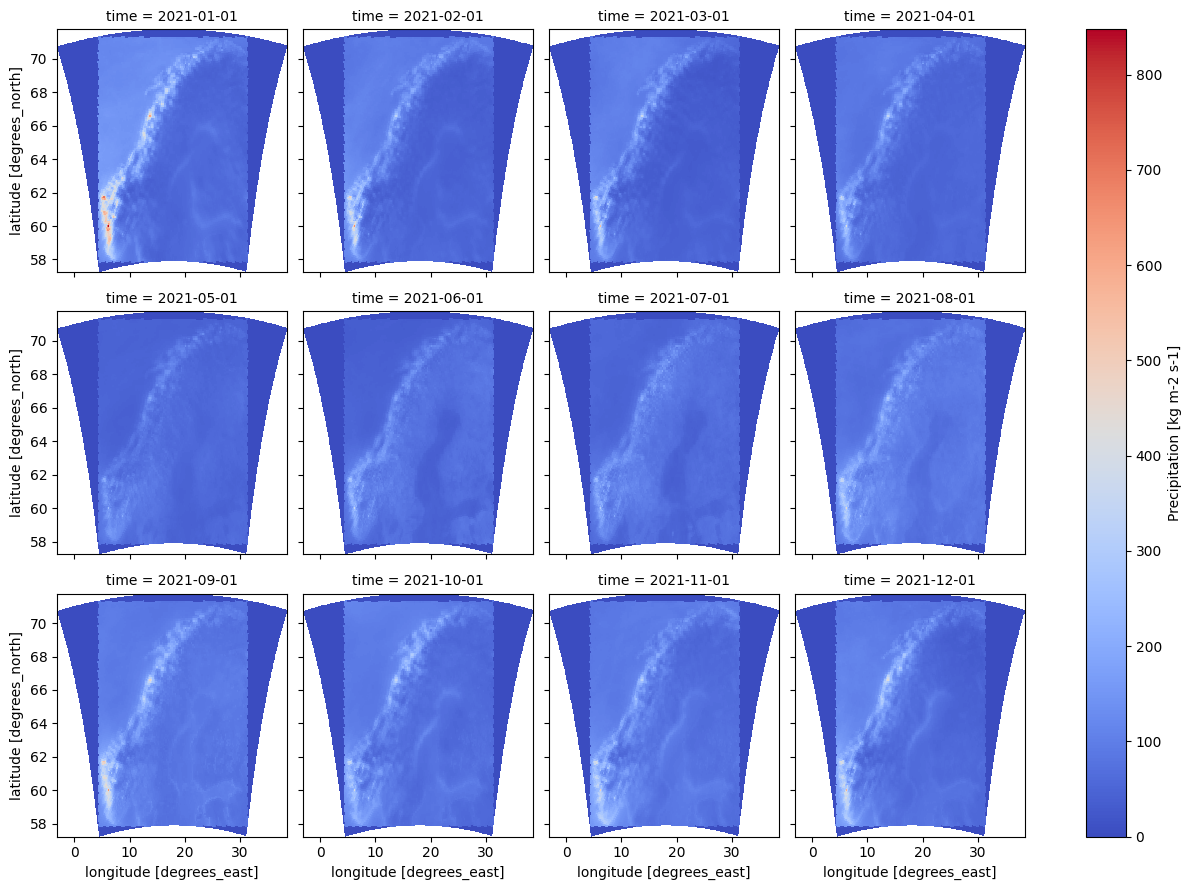

In [71]:
# show months of 2021
grid_means = ds['pr_sum'].sel(scenario='rcp26').mean(dim='ensemble')
grid_means.isel(time=slice(0, 12)).plot(x="lon", y="lat", col='time', col_wrap=4, cmap="coolwarm")

In [7]:
# aggregate with partial overlaps
# TOOD: switch to different library and method
import xagg
ds_renamed = ds_ens.drop_vars(['lon', 'lat']).rename({'rlon':'lon', 'rlat':'lat'})
print(ds_renamed)
weightmap = xagg.pixel_overlaps(ds_renamed, org_units)
aggregated = xagg.aggregate(ds_renamed, weightmap)
ds_org_units = aggregated.to_dataset()[['tas_mean_ens_mean', 'tas_mean_ens_min', 'tas_mean_ens_max', 'id']]
ds_org_units

<xarray.Dataset> Size: 2MB
Dimensions:            (time: 360, scenario: 2, lon: 13, lat: 14)
Coordinates:
  * time               (time) datetime64[ns] 3kB 2021-01-01 ... 2050-12-01
  * scenario           (scenario) <U5 40B 'rcp26' 'rcp85'
  * lon                (lon) float64 104B -13.09 -12.87 -12.65 ... -10.67 -10.45
  * lat                (lat) float64 112B 6.93 7.15 7.37 7.59 ... 9.35 9.57 9.79
    height             float64 8B 2.0
Data variables:
    tas_mean_ens_mean  (scenario, time, lat, lon) float32 524kB 26.83 ... 23.69
    tas_mean_ens_min   (scenario, time, lat, lon) float32 524kB 25.05 ... 22.47
    tas_mean_ens_max   (scenario, time, lat, lon) float32 524kB 28.9 ... 25.89
creating polygons for each pixel...
lat/lon bounds not found in dataset; they will be created.
calculating overlaps between pixels and output polygons...
success!
aggregating tas_mean_ens_mean...
aggregating tas_mean_ens_min...
aggregating tas_mean_ens_max...
all variables aggregated to polygons!


<xarray.Dataset> Size: 228kB
Dimensions:            (poly_idx: 13, scenario: 2, time: 360)
Coordinates:
  * poly_idx           (poly_idx) int64 104B 0 1 2 3 4 5 6 7 8 9 10 11 12
  * scenario           (scenario) <U5 40B 'rcp26' 'rcp85'
  * time               (time) datetime64[ns] 3kB 2021-01-01 ... 2050-12-01
Data variables:
    tas_mean_ens_mean  (poly_idx, scenario, time) float64 75kB 23.98 ... 26.82
    tas_mean_ens_min   (poly_idx, scenario, time) float64 75kB 21.38 ... 25.62
    tas_mean_ens_max   (poly_idx, scenario, time) float64 75kB 25.94 ... 28.55
    id                 (poly_idx) object 104B 'O6uvpzGd5pu' ... 'at6UHUQatSo'

(<Figure size 640x480 with 2 Axes>,
 <GeoAxes: title={'center': 'Poly #0: O6uvpzGd5pu; OU_264; Bo; 2; ImspTQPwCqd'}>)

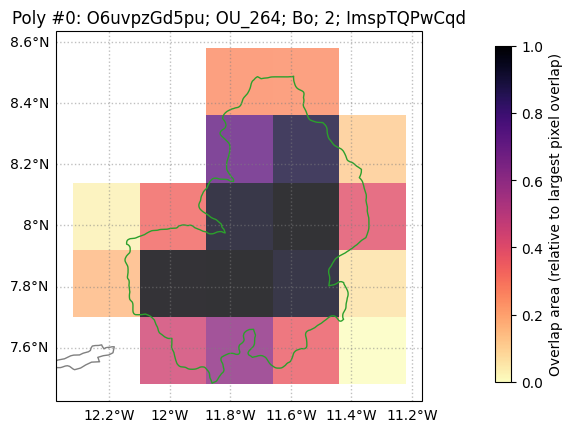

In [28]:
# diagnostic visualization of pixel overlaps
weightmap.diag_fig(0, ds_renamed)

In [8]:
dataframe = ds_org_units.to_dataframe().reset_index()
dataframe

,poly_idx,scenario,time,tas_mean_ens_mean,tas_mean_ens_min,tas_mean_ens_max,id
0,0,rcp26,2021-01-01,23.983950,21.380792,25.939332,O6uvpzGd5pu
1,0,rcp26,2021-02-01,27.090190,23.627411,30.017374,O6uvpzGd5pu
2,0,rcp26,2021-03-01,28.423938,25.907348,30.931780,O6uvpzGd5pu
3,0,rcp26,2021-04-01,28.154160,26.387304,29.992047,O6uvpzGd5pu
4,0,rcp26,2021-05-01,27.031477,25.731531,28.343755,O6uvpzGd5pu
...,...,...,...,...,...,...,...
9355,12,rcp85,2050-08-01,26.477106,25.981306,27.703427,at6UHUQatSo
9356,12,rcp85,2050-09-01,26.864112,26.262023,28.094062,at6UHUQatSo
9357,12,rcp85,2050-10-01,27.615861,26.950367,28.982537,at6UHUQatSo
9358,12,rcp85,2050-11-01,28.153510,26.918969,29.567376,at6UHUQatSo


## Create metadata

In [11]:
data_elements = [
    {
        "name": "2m Temperature, Mean (CORDEX RCP 8.5, Ensemble Mean)",
        "shortName": "Temp Mean - RCP85 Ens Mean",
        "code": "TEMP_MEAN_DAILY_MEAN_ENS_MEAN_RCP85_CORDEX",
        "valueType": "NUMBER",
        "aggregationType": "AVERAGE",
        "domainType": "AGGREGATE"
    },
    {
        "name": "2m Temperature, Mean (CORDEX RCP 8.5, Ensemble Min)",
        "shortName": "Temp Mean - RCP85 Ens Min",
        "code": "TEMP_MEAN_DAILY_MEAN_ENS_MIN_RCP85_CORDEX",
        "valueType": "NUMBER",
        "aggregationType": "AVERAGE",
        "domainType": "AGGREGATE"
    },
    {
        "name": "2m Temperature, Mean (CORDEX RCP 8.5, Ensemble Max)",
        "shortName": "Temp Mean - RCP85 Ens Max",
        "code": "TEMP_MEAN_DAILY_MEAN_ENS_MAX_RCP85_CORDEX",
        "valueType": "NUMBER",
        "aggregationType": "AVERAGE",
        "domainType": "AGGREGATE"
    },
]
de_ids = []
for de in data_elements:
    de_created = client.create_data_element(de)
    de_ids.append( de_created['response']['uid'] )
    print(f"Data element creation status: {de_created['status']} and UID: {de_created['response']['uid']}")

Data element creation status: OK and UID: I4I3LyjYpyl
Data element creation status: OK and UID: NEWwUQP9mu1
Data element creation status: OK and UID: unBxcKIL1rK


In [38]:
data_set = {
    "name": "Monthly CORDEX climate projections", 
    "shortName": "Monthly climate projections",
    "periodType": "Monthly",
    "dataSetElements": [
        {
            "dataElement": {"id": de_id},
        }
        for de_id in de_ids
    ]
}

data_set_created = client.create_data_set(data_set)
print(f"Data set creation status: {data_set_created['status']} and UID: {data_set_created['response']['uid']}")

Data set creation status: OK and UID: uCAqKFWakSX


## Import to DHIS2

In [12]:
DRY_RUN = 'false'

In [13]:
payload = dataframe_to_dhis2_json(
    df = dataframe.query("scenario == 'rcp85'"),                        # pandas.DataFrame
    org_unit_col = 'id',            # column containing the org unit id
    period_col = 'time',      # column containing the period
    value_col = 'tas_mean_ens_mean',              # column containing the value
    data_element_id = 'TEMP_MEAN_DAILY_MEAN_ENS_MEAN_RCP85_CORDEX' # id of the DHIS2 data element
)
import_params = {'dryRun': DRY_RUN, 'dataElementIdScheme': 'CODE'}
res = client.post("/api/dataValueSets", json=payload, params=import_params)
res['response']['importCount']

{'imported': 4680, 'updated': 0, 'ignored': 0, 'deleted': 0}

In [14]:
payload = dataframe_to_dhis2_json(
    df = dataframe.query("scenario == 'rcp85'"),                        # pandas.DataFrame
    org_unit_col = 'id',            # column containing the org unit id
    period_col = 'time',      # column containing the period
    value_col = 'tas_mean_ens_min',              # column containing the value
    data_element_id = 'TEMP_MEAN_DAILY_MEAN_ENS_MIN_RCP85_CORDEX' # id of the DHIS2 data element
)
import_params = {'dryRun': DRY_RUN, 'dataElementIdScheme': 'CODE'}
res = client.post("/api/dataValueSets", json=payload, params=import_params)
res['response']['importCount']

{'imported': 4680, 'updated': 0, 'ignored': 0, 'deleted': 0}

In [15]:
payload = dataframe_to_dhis2_json(
    df = dataframe.query("scenario == 'rcp85'"),                        # pandas.DataFrame
    org_unit_col = 'id',            # column containing the org unit id
    period_col = 'time',      # column containing the period
    value_col = 'tas_mean_ens_max',              # column containing the value
    data_element_id = 'TEMP_MEAN_DAILY_MEAN_ENS_MAX_RCP85_CORDEX' # id of the DHIS2 data element
)
import_params = {'dryRun': DRY_RUN, 'dataElementIdScheme': 'CODE'}
res = client.post("/api/dataValueSets", json=payload, params=import_params)
res['response']['importCount']

{'imported': 4680, 'updated': 0, 'ignored': 0, 'deleted': 0}